In [103]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"C:\Users\Ahmed\Desktop\Data Analysis Projects\GitHup Portfolio\Marketing Project\Digital-Marketing-Campaign-Analytics-Dashboard\marketing_dataset.csv")


In [104]:
df.info

<bound method DataFrame.info of       CustomerID  Age  Gender    Income CampaignChannel     CampaignType  \
0           8000   56  Female  136912.0    Social Media  Brand Awareness   
1           8001   69    Male   41760.0           Email        retention   
2           8002   46  FEMALE       NaN             PPC        Awareness   
3           8003   32  female   44085.0             PPC       Conversion   
4           8004   60  Female   83964.0             PPC       Conversion   
...          ...  ...     ...       ...             ...              ...   
8236       15093   53    Male   64280.0    Social Media        Retention   
8237        8225   66    Male       NaN             SEO       Conversion   
8238        8271   69    Male   Unknown             PPC        Awareness   
8239        8769   45    Male   20765.0    Social Media    Consideration   
8240        8614   56  Female   31171.0          E-mail       conversion   

          AdSpend  ClickThroughRate      ConversionRate

In [105]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Income', 'CampaignChannel',
       'CampaignType', 'AdSpend', 'ClickThroughRate', 'ConversionRate',
       'WebsiteVisits', 'PagesPerVisit', 'TimeOnSite', 'SocialShares',
       'EmailOpens', 'EmailClicks', 'PreviousPurchases', 'LoyaltyPoints',
       'AdvertisingPlatform', 'AdvertisingTool', 'Conversion',
       'CampaignStartDate'],
      dtype='object')

In [106]:
# removing duplicates
duplicates = df[df.duplicated()]
df.drop_duplicates(inplace=True)
duplicates

,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,...,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion,CampaignStartDate
8006,13506,47,Female,62851.0,NaN,conversion,3931.248617,0.283286,0.0549229056138444,28,...,13.474736544469245,56,10.0,6,6,3216,IsConfid,ToolConfid,1,2023-06-11 00:00:00
8012,9140,29,Female,127890.0,Email,Conversion,1116.746744,0.295563,0.0477425890195803,32,...,9.236313842552256,38,15.0,4,3,2799,IsConfid,ToolConfid,1,2023-02-05 00:00:00
8014,15002,19,Female,95604.0,Referral,Conversion,3434.674864,0.124986,0.1077379310648335,18,...,14.580812398582191,99,11.0,7,0,3068,IsConfid,ToolConfid,1,2023-09-23 00:00:00
8017,9266,64,Male,50996.0,SEO,Customer Retention,1096.555433,0.039891,0.0118077285666576,18,...,3.247482140669783,55,4.0,2,0,2680,IsConfid,ToolConfid,0,2023-05-28 00:00:00
8018,8984,41,Male,23405.0,SEO,Awareness,9205.669875,0.180831,0.1333798131292003,40,...,6.67766736284084,39,0.0,8,4,2302,IsConfid,ToolConfid,1,2023-05-30 00:00:00
8020,15922,60,Female,28806.0,PPC,Consideration,5872.469168,0.254213,0.1542573691888155,33,...,1.371829816642531,26,5.0,3,3,2959,IsConfid,ToolConfid,1,2023-09-21 00:00:00
8024,13283,33,Female,43867.0,Ref,Consideration,6343.461548,0.095674,0.1372489045276164,12,...,Unknown,NaN,16.0,6,8,2834,IsConfid,ToolConfid,1,2023-11-17 00:00:00
8030,15601,58,Female,137105.0,Referral,Retention,1881.864509,0.290755,0.1767861934866914,14,...,4.694093718566373,19,5.0,3,1,3684,IsConfid,ToolConfid,0,2023-05-28 00:00:00
8031,9741,21,Female,91727.0,SEO,Consideration,7853.790438,0.101622,0.1170153250455441,38,...,9.492768307222171,54,13.0,6,7,1372,IsConfid,ToolConfid,1,2023-04-10 00:00:00
8033,15015,68,Female,134349.0,ppc,Awareness,309.959701,0.266189,0.1530157655948434,46,...,8.9240284221338,59,12.0,3,7,4352,IsConfid,ToolConfid,1,2023-06-05 00:00:00


In [107]:
# Age Cleaning 
df['Age'].isna().sum()

np.int64(0)

Age range: 16.0 - 69.0


C:\Users\Ahmed\AppData\Local\Temp\ipykernel_26304\576028487.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(fill_value, inplace=True)


<Axes: >

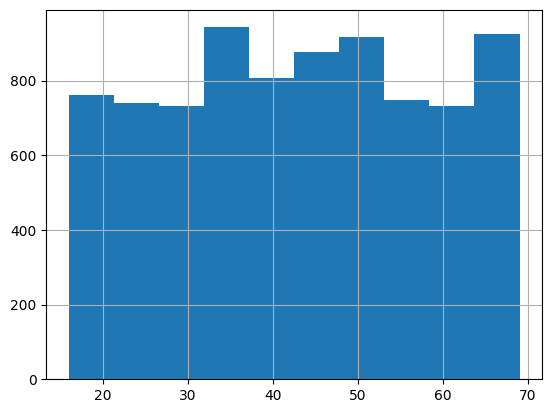

In [108]:
df.loc[(df['Age'] < 16) | (df['Age'] > 100), 'Age'] = np.nan
    
valid_ages = df['Age'].dropna()
fill_value = valid_ages.median()  
    
df['Age'].fillna(fill_value, inplace=True)
    
print(f"Age range: {df['Age'].min()} - {df['Age'].max()}")
df['Age'].hist()

In [109]:
# Gender Cleaning
df['Gender'].unique()

array(['Female', 'Male', 'FEMALE', 'female', 'F', 'M', 'Man', 'masculine',
       ' Female ', ' Male ', 'feminine', '  Female', '  F', 'Woman',
       'MALE', 'Male  ', ' masculine ', '  Male', 'male', 'Female  ', 'm',
       '  feminine', 'feminine  ', 'Woman  ', '  FEMALE', 'Man  ', 'M  ',
       ' Woman ', 'FEMALE  ', '  female', ' feminine ', ' FEMALE ', ' M ',
       ' male ', 'WOMAN', ' Man ', '  masculine', 'female  ', 'f',
       'MALE  ', 'male  ', 'man', 'FEMININE', '  male', 'MAN', '  Man',
       'woman', '  MALE', 'masculine  ', ' female '], dtype=object)

In [110]:
df['Gender'].isna().sum()

np.int64(0)

In [111]:
df['Gender'] = df['Gender'].apply(lambda x: 'Female' if isinstance(x, str) and x.strip().lower().startswith('f') or x.strip().lower() == 'woman' else 'Male')
df['Gender'].unique()

array(['Female', 'Male'], dtype=object)

In [112]:
# Income cleaning
df['Income'] = pd.to_numeric(df['Income'], errors='coerce')
df['Income'].describe()


count      7545.000000
mean      89751.045726
std       52952.387843
min       20018.000000
25%       52483.000000
50%       86224.000000
75%      118738.000000
max      498902.000000
Name: Income, dtype: float64

In [113]:
df['Income'].isna().sum()


np.int64(637)

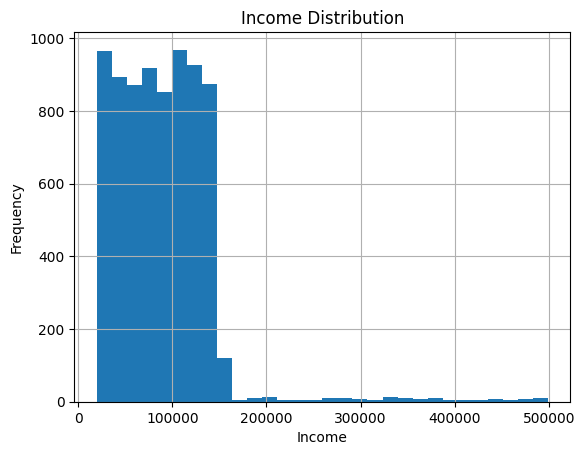

In [114]:
import matplotlib.pyplot as plt

df['Income'].hist(bins=30)
plt.title('Income Distribution')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.show()


In [115]:
df['Income'] = df['Income'].fillna(value=df["Income"].median())


In [116]:
# CampaignChannel Cleaning
df['CampaignChannel'].isna().sum()
df['CampaignChannel'].unique()

array(['Social Media', 'Email', 'PPC', 'REFERRAL', 'social media', 'SEO',
       ' Email ', ' Social Media ', nan, 'Referral', 'e-mail', 'Ref',
       'Paid Search', 'SocialMedia', 'ppc', 'SEO  ', 'Referrals',
       'referral', 'EMAIL', 'PayPerClick', 'Social_Media', 'Unknown',
       'email', 'Pay-Per-Click', 'E-mail', ' PPC ', 'Referal', 'Email  ',
       ' e-mail ', 'seo', 'SM', 'Social Media  ', '  PPC', 'SOCIAL MEDIA',
       '  SEO', ' E-mail ', 'sm', 'E-mail  ', ' Referral ', 'Referral  ',
       ' SEO ', '  Referral', 'e-mail  ', 'PPC  ', 'Paid Search  ',
       'SM  ', '  Referal', 'E-MAIL', '  Social Media', '  referral',
       ' email ', '  Ref', '  SM', 'pay-per-click', ' Pay-Per-Click ',
       'ppc  ', '  Email', '  Pay-Per-Click', 'payperclick', 'UNKNOWN',
       'PAY-PER-CLICK', 'Pay-Per-Click  ', 'referal', 'Paid_Search',
       'email  ', 'SOCIALMEDIA', 'SOCIAL_MEDIA', ' PayPerClick ', 'Ref  ',
       '  ppc', 'Referrals  ', ' SM ', ' Social_Media ', 'PayPerClick  '

In [117]:

df['CampaignChannel'] = df['CampaignChannel'].str.lower()
df['CampaignChannel'] = df['CampaignChannel'].str.strip()
df['CampaignChannel'] = df['CampaignChannel'].apply(
    lambda x: 'social media' if isinstance(x, str) and x.startswith('social') or x == 'sm' else x
)
df['CampaignChannel'] = df['CampaignChannel'].apply(lambda x: 'E-mail' if x == 'email' or x == 'e-mail' else x)
df['CampaignChannel'] = df['CampaignChannel'].apply(
    lambda x: 'payperclick' if (isinstance(x, str) and x.startswith('p') and x != 'paid_search') else x
)
df['CampaignChannel'] = df['CampaignChannel'].apply(
    lambda x: 'referral' if isinstance(x, str) and x.startswith('ref') else x
)
df['CampaignChannel'] = df['CampaignChannel'].apply(lambda x: 'unknown' if x == 'n/a' else x)
df['CampaignChannel'].fillna(value='unknown', inplace=True)
df['CampaignChannel'].unique()

C:\Users\Ahmed\AppData\Local\Temp\ipykernel_26304\1957290753.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CampaignChannel'].fillna(value='unknown', inplace=True)


array(['social media', 'E-mail', 'payperclick', 'referral', 'seo',
       'unknown', 'paid_search'], dtype=object)

In [118]:
# CampaignType Cleaning
df['CampaignType'].isna().sum()

np.int64(0)

In [119]:
df['CampaignType'].unique()


array(['Brand Awareness', 'retention', 'Awareness', 'Conversion',
       'AWARENESS', 'Retention', ' awareness ', 'Awareness  ', 'Convert',
       'Consideration', 'Conv', 'awareness', '  AWARENESS', 'conversion',
       ' Convert ', 'consideration', '  Awareness', ' Consideration ',
       'Retain', 'Retention  ', 'CONVERSION', 'Customer Retention',
       'Conversion  ', ' Retention ', 'Consideration  ', '  Conversion',
       ' Conv ', '  Consideration', 'AWARENESS  ', 'customer retention',
       'Convert  ', ' Conversion ', 'RETENTION', '  Retention',
       ' Awareness ', '  Convert', ' Retain ', '  Brand Awareness',
       '  Conv', 'CONSIDERATION', 'BRAND AWARENESS', 'Brand Awareness  ',
       'awareness  ', 'retention  ', 'Conv  ', 'conversion  ', 'CONV',
       'Retain  ', ' Customer Retention ', 'brand awareness',
       ' retention ', 'CUSTOMER RETENTION', '  awareness', 'conv',
       'Customer_Retention', '  Customer Retention', 'convert', 'retain',
       'RETAIN', 'Bra

In [120]:
df['CampaignType'] = df['CampaignType'].apply(lambda x:
    'Brand Awareness' if isinstance(x, str) and x.lower().strip().endswith('awareness')
    else 'Customer Retention' if isinstance(x, str) and (
        x.lower().strip().startswith('ret') or 
        x.lower().strip() == 'retain' or 
        x.lower().strip() == 'customer retention' or
        x.lower().strip() == 'customer_retention'
    )
    else 'Conversion' if isinstance(x, str) and x.lower().strip().startswith('conv')
    else 'Consideration'
)


In [121]:
df['CampaignType'].unique()

array(['Brand Awareness', 'Customer Retention', 'Conversion',
       'Consideration'], dtype=object)

In [122]:
# AdSpend Cleaning not finished 
df['AdSpend'].isna().sum()

np.int64(0)

In [123]:
df['AdSpend'].describe()

count    8.182000e+03
mean     3.658227e+70
std      3.109046e+72
min     -9.671659e+02
25%      2.209290e+03
50%      4.814451e+03
75%      7.325453e+03
max      2.806448e+74
Name: AdSpend, dtype: float64

In [124]:
df['AdSpend'] = pd.to_numeric(df['AdSpend'], errors='coerce')

df.loc[df['AdSpend'] < 0, 'AdSpend'] = 0 

adspend_cap = df['AdSpend'].quantile(0.999)
df.loc[df['AdSpend'] > adspend_cap, 'AdSpend'] = adspend_cap

df['AdSpend'] = df['AdSpend'].fillna(df['AdSpend'].median()) 

In [125]:
# ConversionRate Cleaning
df['ConversionRate'].isna().sum()

np.int64(210)

In [126]:
df['ConversionRate'].describe()

count        7972
unique       7795
top       Unknown
freq           27
Name: ConversionRate, dtype: object

In [127]:
df['ConversionRate'] = pd.to_numeric(df['ConversionRate'], errors='coerce')

In [128]:
df['ConversionRate'].describe()

count    7945.000000
mean        0.256002
std         0.699645
min         0.010020
25%         0.058572
50%         0.109057
75%         0.159504
max         4.984962
Name: ConversionRate, dtype: float64

<Axes: >

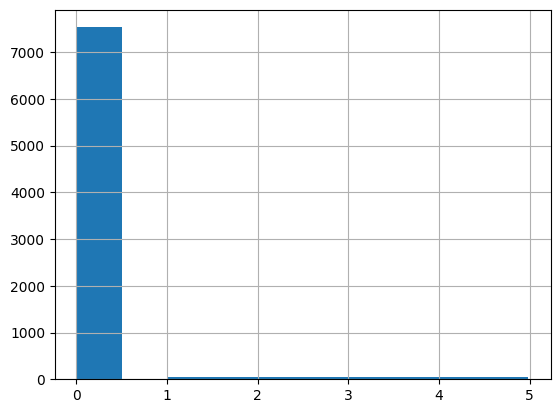

In [129]:
df['ConversionRate'].hist()

In [130]:
df.loc[(df['ConversionRate']>1),'ConversionRate'] = np.nan
valid_ConvRate = df['ConversionRate'].dropna()
fill_valuee = valid_ConvRate.mean()  # More robust than mean
    
# Step 3: Fill missing values
df['ConversionRate'].fillna(fill_valuee, inplace=True)

C:\Users\Ahmed\AppData\Local\Temp\ipykernel_26304\1198806181.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ConversionRate'].fillna(fill_valuee, inplace=True)


In [131]:
df['TimeOnSite'].isna().sum()

np.int64(481)

In [132]:
df['TimeOnSite'].describe()

count        7701
unique       7441
top       Unknown
freq           89
Name: TimeOnSite, dtype: object

In [133]:
df['TimeOnSite'].unique()

array(['7.396802580796058', '5.352548601242156', nan, ...,
       '14.22779429096507', '14.618323406204016', '12.76365976210446'],
      shape=(7442,), dtype=object)

In [134]:
df['TimeOnSite'] = pd.to_numeric(df['TimeOnSite'], errors='coerce')

<Axes: >

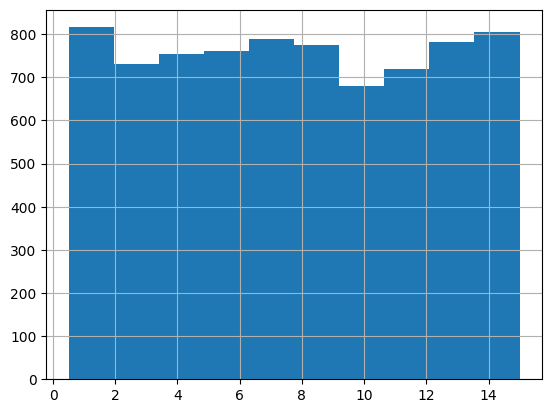

In [135]:
df['TimeOnSite'].hist()

In [136]:
df['TimeOnSite'].fillna(value=df['TimeOnSite'].mean(), inplace=True)

C:\Users\Ahmed\AppData\Local\Temp\ipykernel_26304\4165667736.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TimeOnSite'].fillna(value=df['TimeOnSite'].mean(), inplace=True)


In [137]:
df['SocialShares'].describe()

count        7189
unique        101
top       Unknown
freq          232
Name: SocialShares, dtype: object

In [138]:
df['SocialShares'].isna().sum()

np.int64(993)

In [139]:
df['SocialShares']

0        19
1         5
2         0
3        89
4       NaN
       ... 
8236     69
8237     17
8238     44
8239     21
8240     57
Name: SocialShares, Length: 8182, dtype: object

In [140]:
df['SocialShares'] = pd.to_numeric(df['SocialShares'], errors='coerce')
df['SocialShares'].fillna(value=df['SocialShares'].mean(), inplace=True)


C:\Users\Ahmed\AppData\Local\Temp\ipykernel_26304\2106002132.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['SocialShares'].fillna(value=df['SocialShares'].mean(), inplace=True)


In [141]:
# EmailOpens Cleaning
df['EmailOpens'].describe()

count     7377
unique      21
top        9.0
freq       382
Name: EmailOpens, dtype: object

In [142]:
df['EmailOpens'].isna().sum()

np.int64(805)

<Axes: >

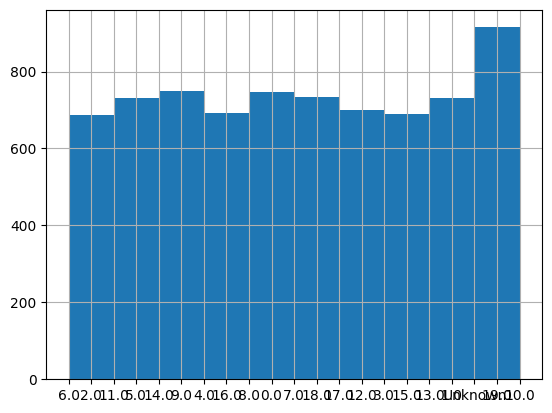

In [143]:
df['EmailOpens'].hist()

In [144]:
df['EmailOpens'] = pd.to_numeric(df['EmailOpens'], errors='coerce')
df['EmailOpens'].fillna(value=df['EmailOpens'].mean(), inplace=True)

C:\Users\Ahmed\AppData\Local\Temp\ipykernel_26304\3373074826.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['EmailOpens'].fillna(value=df['EmailOpens'].mean(), inplace=True)


In [145]:
# CampaignStartDate Cleaning 
df['CampaignStartDate'].describe()

count                    8182
unique                    366
top       2023-06-19 00:00:00
freq                       40
Name: CampaignStartDate, dtype: object

In [146]:
df['CampaignStartDate'].isna().sum()

np.int64(0)

In [147]:
df['CampaignStartDate'] = pd.to_datetime(df['CampaignStartDate'], errors='coerce')
df['FormattedStartDate'] = df['CampaignStartDate'].dt.strftime('%d-%m-%Y')

In [148]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
8236    False
8237    False
8238    False
8239    False
8240    False
Length: 8182, dtype: bool

In [149]:
df['Conversion'].describe()

count    8182.000000
mean        0.880103
std         0.324861
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: Conversion, dtype: float64

In [150]:
# saving the results of the cleaning
output_file_path = r"C:\Users\Ahmed\Desktop\Data Analysis Projects\GitHup Portfolio\Marketing Project\Digital-Marketing-Campaign-Analytics-Dashboard\marketing_dataset_cleaned.csv"
df.to_csv(output_file_path, index=False)